In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
DATA_DIR = Path("../../example/filter_mass_diff_and_size")

FILES = {
    1: DATA_DIR / "filtered_pairs_800_1000_HiGHS_CMD_threads_1_original.csv",
    2: DATA_DIR / "filtered_pairs_800_1000_HiGHS_CMD_threads_2_original.csv",
    4: DATA_DIR / "filtered_pairs_800_1000_HiGHS_CMD_threads_4_original.csv",
    8: DATA_DIR / "filtered_pairs_800_1000_HiGHS_CMD_threads_8_original.csv",
}

dataframes = []

for threads, file_path in FILES.items():
    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path.resolve()}")

    df = pd.read_csv(file_path)
    df["threads"] = threads

    # A row is considered timed out when this message is present.
    df["timed_out"] = (
        df["error_message"]
        .fillna("")
        .str.contains("Exceeded 60 seconds", case=False)
    )

    # Successfully completed means that an MCES runtime and result exist.
    df["completed"] = (
        df["runtime_inside_mces"].notna()
        & df["distance"].notna()
        & ~df["timed_out"]
    )

    dataframes.append(df)

all_results = pd.concat(dataframes, ignore_index=True)

print(f"Total rows loaded: {len(all_results)}")
print(f"Number of thread configurations: {all_results['threads'].nunique()}")

display(all_results.head())

Total rows loaded: 556
Number of thread configurations: 4


,pair_id,smiles1,smiles2,mass1,mass2,mass_diff,runtime_sec,runtime_inside_mces,distance,compute_mode,...,structural_lb,skipped_by_structural_lb,raw_mces_result,error_message,result_type,is_exact,is_lower_bound,threads,timed_out,completed
0,964,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCCCCCCCC)(COP(O...,CCCCC[C@H](O)\C=C\[C@@H]1[C@@H](C\C=C/CCCC(=O)...,819.155,819.026,1.290000e-01,13.359516,10.586510,10.0,2.0,...,NaN,0,"(0, 10, 10.586510181427002, 2, 1, 10)",NaN,lower_bound,0,1,1,False,True
1,1073,[H][C@](COC(=O)CCCCCCCCCCCCC)(COC(=O)CCCCCCCCC...,[H][C@](COC(=O)CCCCCCCCCCCCCCCCCCCC)(COC(=O)CC...,849.420,849.420,1.136868e-13,60.000000,NaN,NaN,NaN,...,NaN,0,NaN,Exceeded 60 seconds,unknown,0,0,1,True,False
2,1586,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCCCC(C)C)(COC(=...,[H][C@@](COC(=O)CC\C=C/CC(O)\C=C/C=C\C\C=C/C\C...,849.420,848.068,1.352000e+00,1.505086,0.004861,21.0,2.0,...,NaN,0,"(0, 21.0, 0.004860639572143555, 2)",NaN,lower_bound,0,1,1,False,True
3,3772,[H][C@@](COC(=O)CCCCCCCCCCCCCCCCCCCCC(C)C)(COC...,CCCCC[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C@@H]1C...,905.528,905.201,3.270000e-01,1.363290,0.002991,19.0,2.0,...,NaN,0,"(0, 19.0, 0.0029914379119873047, 2)",NaN,lower_bound,0,1,1,False,True
4,3995,[H][C@@](CO\C=C\CCCCCCCCCCCCCCCC)(COP([O-])(=O...,[H][C@](COC(=O)CCCCCCCCCCCCCC)(COC(=O)CCCCCCCC...,808.135,807.339,7.960000e-01,1.291307,0.003131,17.0,2.0,...,NaN,0,"(0, 17.0, 0.003131389617919922, 2)",NaN,lower_bound,0,1,1,False,True


In [20]:
pair_counts = (
    all_results.groupby("threads")["pair_id"]
    .nunique()
    .rename("unique_pairs")
    .reset_index()
)

display(pair_counts)

pairs_per_thread = {
    threads: set(df["pair_id"])
    for threads, df in all_results.groupby("threads")
}

reference_pairs = pairs_per_thread[1]

for threads, pairs in pairs_per_thread.items():
    missing = reference_pairs - pairs
    additional = pairs - reference_pairs

    print(
        f"{threads} threads: "
        f"{len(missing)} missing pairs, "
        f"{len(additional)} additional pairs"
    )

,threads,unique_pairs
0,1,139
1,2,139
2,4,139
3,8,139


1 threads: 0 missing pairs, 0 additional pairs
2 threads: 0 missing pairs, 0 additional pairs
4 threads: 0 missing pairs, 0 additional pairs
8 threads: 0 missing pairs, 0 additional pairs


In [21]:
summary = (
    all_results.groupby("threads")
    .agg(
        total_pairs=("pair_id", "count"),
        completed_pairs=("completed", "sum"),
        timeout_count=("timed_out", "sum"),
        solver_calls=("solverCalled", "sum"),
        exact_results=("is_exact", "sum"),
        lower_bound_results=("is_lower_bound", "sum"),
        total_runtime_sec=("runtime_sec", "sum"),
        mean_runtime_sec=("runtime_sec", "mean"),
        median_runtime_sec=("runtime_sec", "median"),
        min_runtime_sec=("runtime_sec", "min"),
        max_runtime_sec=("runtime_sec", "max"),
    )
    .reset_index()
)

summary["timeout_rate_percent"] = (
    100 * summary["timeout_count"] / summary["total_pairs"]
)

summary["solver_call_rate_percent"] = (
    100 * summary["solver_calls"] / summary["total_pairs"]
)

summary = summary.round(3)

display(summary)

,threads,total_pairs,completed_pairs,timeout_count,solver_calls,exact_results,lower_bound_results,total_runtime_sec,mean_runtime_sec,median_runtime_sec,min_runtime_sec,max_runtime_sec,timeout_rate_percent,solver_call_rate_percent
0,1,139,107,32,40,29,78,2643.563,19.018,5.151,1.098,60.0,23.022,28.777
1,2,139,111,28,44,33,78,2479.274,17.837,5.233,0.938,60.0,20.144,31.655
2,4,139,113,26,46,35,78,2433.387,17.506,4.906,0.934,60.0,18.705,33.094
3,8,139,114,25,47,36,78,2404.670,17.300,4.606,1.000,60.0,17.986,33.813


In [22]:
completed_summary = (
    all_results[all_results["completed"]]
    .groupby("threads")
    .agg(
        completed_pairs=("pair_id", "count"),
        total_completed_runtime_sec=("runtime_sec", "sum"),
        mean_completed_runtime_sec=("runtime_sec", "mean"),
        median_completed_runtime_sec=("runtime_sec", "median"),
        std_completed_runtime_sec=("runtime_sec", "std"),
        mean_mces_runtime_sec=("runtime_inside_mces", "mean"),
        median_mces_runtime_sec=("runtime_inside_mces", "median"),
    )
    .reset_index()
    .round(3)
)

display(completed_summary)

,threads,completed_pairs,total_completed_runtime_sec,mean_completed_runtime_sec,median_completed_runtime_sec,std_completed_runtime_sec,mean_mces_runtime_sec,median_mces_runtime_sec
0,1,107,723.563,6.762,2.607,7.862,4.698,0.012
1,2,111,799.274,7.201,1.829,10.514,5.667,0.006
2,4,113,873.387,7.729,1.851,12.023,6.329,0.008
3,8,114,904.670,7.936,1.843,12.522,6.439,0.010


In [23]:
solver_results = all_results[
    (all_results["solverCalled"] == 1)
    & all_results["completed"]
].copy()

solver_summary = (
    solver_results.groupby("threads")
    .agg(
        completed_solver_calls=("pair_id", "count"),
        total_solver_pair_runtime_sec=("runtime_sec", "sum"),
        mean_solver_pair_runtime_sec=("runtime_sec", "mean"),
        median_solver_pair_runtime_sec=("runtime_sec", "median"),
        std_solver_pair_runtime_sec=("runtime_sec", "std"),
        mean_runtime_inside_mces=("runtime_inside_mces", "mean"),
        median_runtime_inside_mces=("runtime_inside_mces", "median"),
    )
    .reset_index()
    .round(3)
)

display(solver_summary)

,threads,completed_solver_calls,total_solver_pair_runtime_sec,mean_solver_pair_runtime_sec,median_solver_pair_runtime_sec,std_solver_pair_runtime_sec,mean_runtime_inside_mces,median_runtime_inside_mces
0,1,40,581.163,14.529,13.312,8.136,12.491,11.221
1,2,44,705.648,16.037,12.784,12.229,14.248,11.663
2,4,46,778.785,16.930,13.040,14.614,15.503,11.484
3,8,47,800.971,17.042,10.683,15.468,15.570,9.033


In [24]:
one_thread_total = summary.loc[
    summary["threads"] == 1,
    "total_runtime_sec"
].iloc[0]

summary["speedup_vs_1_thread"] = (
    one_thread_total / summary["total_runtime_sec"]
)

summary["efficiency_percent"] = (
    100
    * summary["speedup_vs_1_thread"]
    / summary["threads"]
)

summary = summary.round(3)

display(
    summary[
        [
            "threads",
            "total_runtime_sec",
            "speedup_vs_1_thread",
            "efficiency_percent",
            "timeout_count",
        ]
    ]
)

,threads,total_runtime_sec,speedup_vs_1_thread,efficiency_percent,timeout_count
0,1,2643.563,1.000,100.000,32
1,2,2479.274,1.066,53.313,28
2,4,2433.387,1.086,27.159,26
3,8,2404.670,1.099,13.742,25


In [43]:
FILES = {
    1: DATA_DIR / "filtered_pairs_800_1000_HiGHS_CMD_threads_1_original.csv",
    2: DATA_DIR / "filtered_pairs_800_1000_HiGHS_CMD_threads_2_original.csv",
    4: DATA_DIR / "filtered_pairs_800_1000_HiGHS_CMD_threads_4_original.csv",
    8: DATA_DIR / "filtered_pairs_800_1000_HiGHS_CMD_threads_8_original.csv",
}

TIME_LIMIT = 60


# Read and combine the four files
all_results = []

for threads, file_path in FILES.items():
    df = pd.read_csv(file_path)

    df["threads"] = threads

    # A run is considered a timeout when its runtime reaches the time limit
    df["timed_out"] = df["runtime_sec"] >= TIME_LIMIT

    all_results.append(
        df[
            [
                "pair_id",
                "threads",
                "runtime_sec",
                "timed_out",
            ]
        ]
    )

all_results = pd.concat(
    all_results,
    ignore_index=True,
)


# Get the 1-thread runtime for every pair
one_thread = (
    all_results.loc[
        all_results["threads"] == 1,
        [
            "pair_id",
            "runtime_sec",
            "timed_out",
        ],
    ]
    .rename(
        columns={
            "runtime_sec": "runtime_1_thread",
            "timed_out": "timeout_1_thread",
        }
    )
)


# Add the 1-thread result to every thread configuration
comparison = all_results.merge(
    one_thread,
    on="pair_id",
    how="inner",
)


# A comparison is valid only when neither run timed out
comparison["valid_comparison"] = (
    ~comparison["timed_out"]
    & ~comparison["timeout_1_thread"]
)


# Check whether the pair is faster than with 1 thread
comparison["faster_than_1_thread"] = (
    comparison["valid_comparison"]
    & (
        comparison["runtime_sec"]
        < comparison["runtime_1_thread"]
    )
)


# Calculate speedup for each individual pair
comparison["pair_speedup"] = np.where(
    comparison["valid_comparison"],
    comparison["runtime_1_thread"]
    / comparison["runtime_sec"],
    np.nan,
)


# Build the summary
summary = (
    comparison
    .groupby("threads", as_index=False)
    .agg(
        total_runtime_sec=("runtime_sec", "sum"),
        pairs_faster_than_1_thread=(
            "faster_than_1_thread",
            "sum",
        ),
        total_compared_pairs=(
            "valid_comparison",
            "sum",
        ),
        mean_pair_speedup=(
            "pair_speedup",
            "mean",
        ),
        median_pair_speedup=(
            "pair_speedup",
            "median",
        ),
        timeout_count=(
            "timed_out",
            "sum",
        ),
    )
)


# Total-runtime speedup relative to 1 thread
one_thread_total = summary.loc[
    summary["threads"] == 1,
    "total_runtime_sec",
].iloc[0]

summary["speedup_vs_1_thread"] = (
    one_thread_total
    / summary["total_runtime_sec"]
)

summary["efficiency_percent"] = (
    100
    * summary["speedup_vs_1_thread"]
    / summary["threads"]
)

summary = summary.round(3)

display(summary)

,threads,total_runtime_sec,pairs_faster_than_1_thread,total_compared_pairs,mean_pair_speedup,median_pair_speedup,timeout_count,speedup_vs_1_thread,efficiency_percent
0,1,2643.563,0,107,1.000,1.000,32,1.000,100.000
1,2,2479.274,85,107,1.524,1.282,28,1.066,53.313
2,4,2433.387,85,107,1.444,1.272,26,1.086,27.159
3,8,2404.670,90,107,1.434,1.298,25,1.099,13.742


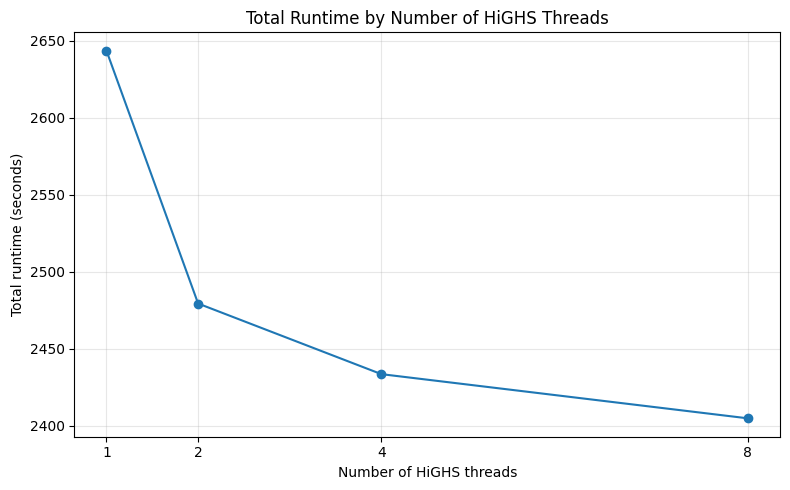

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    summary["threads"],
    summary["total_runtime_sec"],
    marker="o"
)

plt.xticks(summary["threads"])
plt.xlabel("Number of HiGHS threads")
plt.ylabel("Total runtime (seconds)")
plt.title("Total Runtime by Number of HiGHS Threads")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

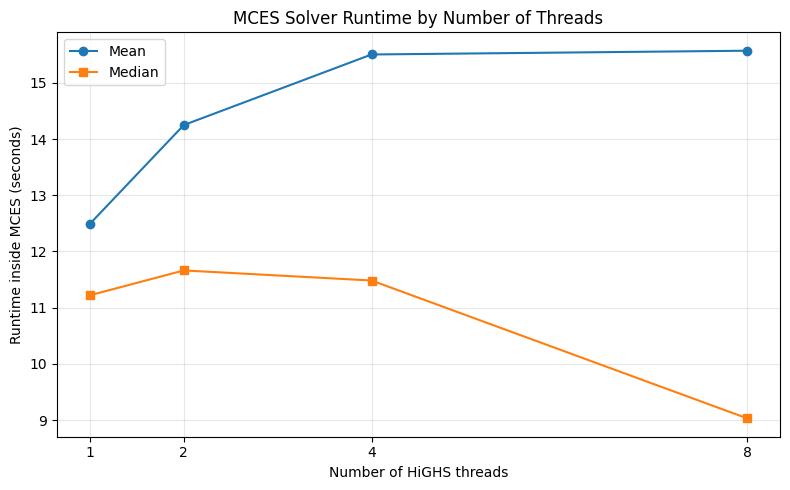

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    solver_summary["threads"],
    solver_summary["mean_runtime_inside_mces"],
    marker="o",
    label="Mean"
)

plt.plot(
    solver_summary["threads"],
    solver_summary["median_runtime_inside_mces"],
    marker="s",
    label="Median"
)

plt.xticks(solver_summary["threads"])
plt.xlabel("Number of HiGHS threads")
plt.ylabel("Runtime inside MCES (seconds)")
plt.title("MCES Solver Runtime by Number of Threads")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

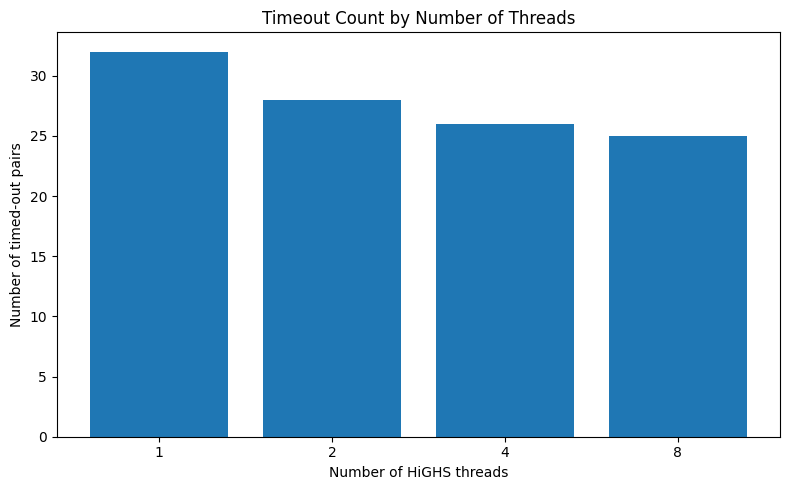

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    summary["threads"].astype(str),
    summary["timeout_count"]
)

plt.xlabel("Number of HiGHS threads")
plt.ylabel("Number of timed-out pairs")
plt.title("Timeout Count by Number of Threads")
plt.tight_layout()
plt.show()

In [28]:
comparison_flags = (
    all_results.groupby("pair_id")
    .agg(
        configurations=("threads", "nunique"),
        completed_in_all=("completed", "sum"),
        solver_called_in_all=("solverCalled", "sum"),
    )
    .reset_index()
)

common_solver_pairs = comparison_flags.loc[
    (comparison_flags["configurations"] == len(FILES))
    & (comparison_flags["completed_in_all"] == len(FILES))
    & (comparison_flags["solver_called_in_all"] == len(FILES)),
    "pair_id"
]

fair_comparison = all_results[
    all_results["pair_id"].isin(common_solver_pairs)
].copy()

print(
    "Pairs completed with solver calls under every thread setting:",
    fair_comparison["pair_id"].nunique()
)

Pairs completed with solver calls under every thread setting: 40


In [29]:
runtime_by_pair = (
    fair_comparison.pivot(
        index="pair_id",
        columns="threads",
        values="runtime_inside_mces"
    )
    .rename(columns=lambda threads: f"threads_{threads}")
    .reset_index()
)

display(runtime_by_pair.head())

threads,pair_id,threads_1,threads_2,threads_4,threads_8
0,964,10.586510,4.858830,4.086670,3.852978
1,7894,16.490989,11.769607,11.465730,8.739527
2,11417,6.561174,9.409376,9.725458,6.480002
3,12707,4.207332,3.756659,4.548034,2.778186
4,16244,20.735562,20.875170,14.147892,8.890752


In [30]:
for threads in [2, 4, 8]:
    runtime_by_pair[f"speedup_1_to_{threads}"] = (
        runtime_by_pair["threads_1"]
        / runtime_by_pair[f"threads_{threads}"]
    )

display(runtime_by_pair.head())

threads,pair_id,threads_1,threads_2,threads_4,threads_8,speedup_1_to_2,speedup_1_to_4,speedup_1_to_8
0,964,10.586510,4.858830,4.086670,3.852978,2.178819,2.590498,2.747618
1,7894,16.490989,11.769607,11.465730,8.739527,1.401150,1.438285,1.886943
2,11417,6.561174,9.409376,9.725458,6.480002,0.697302,0.674639,1.012526
3,12707,4.207332,3.756659,4.548034,2.778186,1.119966,0.925088,1.514417
4,16244,20.735562,20.875170,14.147892,8.890752,0.993312,1.465629,2.332262


In [31]:
pair_speedup_summary = pd.DataFrame({
    "threads": [2, 4, 8],
    "mean_speedup": [
        runtime_by_pair["speedup_1_to_2"].mean(),
        runtime_by_pair["speedup_1_to_4"].mean(),
        runtime_by_pair["speedup_1_to_8"].mean(),
    ],
    "median_speedup": [
        runtime_by_pair["speedup_1_to_2"].median(),
        runtime_by_pair["speedup_1_to_4"].median(),
        runtime_by_pair["speedup_1_to_8"].median(),
    ],
    "pairs_faster_than_1_thread": [
        (runtime_by_pair["speedup_1_to_2"] > 1).sum(),
        (runtime_by_pair["speedup_1_to_4"] > 1).sum(),
        (runtime_by_pair["speedup_1_to_8"] > 1).sum(),
    ],
    "total_compared_pairs": len(runtime_by_pair),
}).round(3)

display(pair_speedup_summary)

,threads,mean_speedup,median_speedup,pairs_faster_than_1_thread,total_compared_pairs
0,2,1.118,1.085,27,40
1,4,1.173,1.077,23,40
2,8,1.324,1.253,36,40


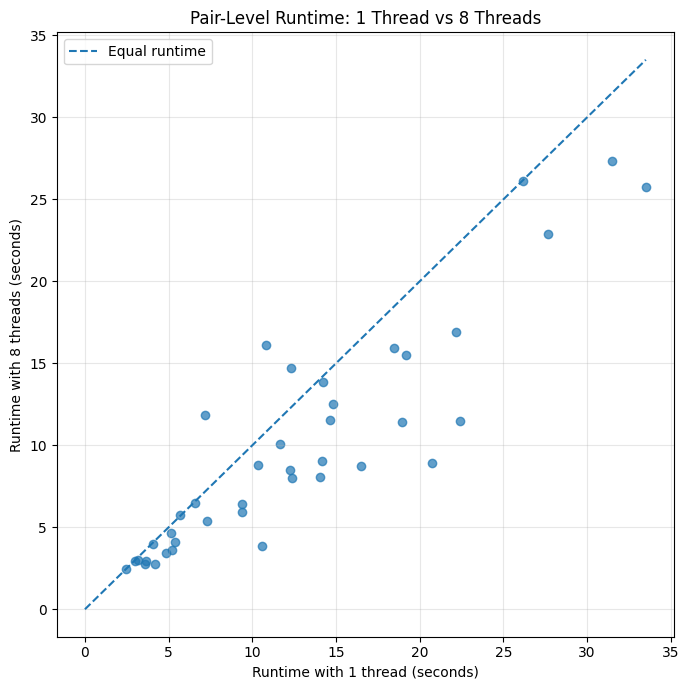

In [32]:
plt.figure(figsize=(7, 7))

plt.scatter(
    runtime_by_pair["threads_1"],
    runtime_by_pair["threads_8"],
    alpha=0.7
)

maximum_runtime = max(
    runtime_by_pair["threads_1"].max(),
    runtime_by_pair["threads_8"].max()
)

plt.plot(
    [0, maximum_runtime],
    [0, maximum_runtime],
    linestyle="--",
    label="Equal runtime"
)

plt.xlabel("Runtime with 1 thread (seconds)")
plt.ylabel("Runtime with 8 threads (seconds)")
plt.title("Pair-Level Runtime: 1 Thread vs 8 Threads")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
runtime_by_pair["change_1_to_8_sec"] = (
    runtime_by_pair["threads_8"]
    - runtime_by_pair["threads_1"]
)

runtime_by_pair["change_1_to_8_percent"] = (
    100
    * runtime_by_pair["change_1_to_8_sec"]
    / runtime_by_pair["threads_1"]
)

fastest_improvements = runtime_by_pair.sort_values(
    "change_1_to_8_percent"
).head(10)

largest_slowdowns = runtime_by_pair.sort_values(
    "change_1_to_8_percent",
    ascending=False
).head(10)

print("Pairs with the largest improvement using 8 threads:")
display(fastest_improvements)

print("Pairs with the largest slowdown using 8 threads:")
display(largest_slowdowns)

Pairs with the largest improvement using 8 threads:


threads,pair_id,threads_1,threads_2,threads_4,threads_8,speedup_1_to_2,speedup_1_to_4,speedup_1_to_8,change_1_to_8_sec,change_1_to_8_percent
0,964,10.586510,4.858830,4.086670,3.852978,2.178819,2.590498,2.747618,-6.733533,-63.604838
4,16244,20.735562,20.875170,14.147892,8.890752,0.993312,1.465629,2.332262,-11.844810,-57.123168
5,16264,22.420152,18.858306,16.828660,11.505599,1.188874,1.332260,1.948630,-10.914553,-48.681885
1,7894,16.490989,11.769607,11.465730,8.739527,1.401150,1.438285,1.886943,-7.751462,-47.004227
16,40818,14.053269,10.926063,10.779498,8.056012,1.286215,1.303704,1.744445,-5.997257,-42.675174
20,57775,18.951521,14.093588,13.301446,11.400558,1.344691,1.424771,1.662333,-7.550963,-39.843572
17,41289,9.371425,8.367022,9.658515,5.960215,1.120043,0.970276,1.572330,-3.411210,-36.400117
39,103398,14.145634,13.478289,10.961843,9.032531,1.049513,1.290443,1.566077,-5.113104,-36.146160
25,64586,12.357267,11.013534,8.629066,7.980880,1.122007,1.432052,1.548359,-4.376387,-35.415493
3,12707,4.207332,3.756659,4.548034,2.778186,1.119966,0.925088,1.514417,-1.429146,-33.967993


Pairs with the largest slowdown using 8 threads:


threads,pair_id,threads_1,threads_2,threads_4,threads_8,speedup_1_to_2,speedup_1_to_4,speedup_1_to_8,change_1_to_8_sec,change_1_to_8_percent
27,69765,7.162701,3.657091,4.038018,11.875657,1.958579,1.773816,0.603141,4.712956,65.798592
32,83609,10.819648,13.100931,12.741658,16.102090,0.825869,0.849155,0.671941,5.282442,48.822680
29,78357,12.284931,13.251018,12.845738,14.705638,0.927093,0.956343,0.835389,2.420708,19.704692
21,58609,5.682560,7.313427,6.611760,5.763351,0.777004,0.859463,0.985982,0.080791,1.421740
6,19287,26.193099,23.920535,17.639517,26.107341,1.095005,1.484910,1.003285,-0.085757,-0.327405
19,46648,2.960569,3.388005,3.815625,2.945130,0.873838,0.775907,1.005242,-0.015439,-0.521473
34,93598,2.462877,3.632974,3.234346,2.436421,0.677923,0.761476,1.010858,-0.026456,-1.074176
2,11417,6.561174,9.409376,9.725458,6.480002,0.697302,0.674639,1.012526,-0.081172,-1.237149
35,97919,4.053192,5.064369,4.106617,3.990771,0.800335,0.986990,1.015641,-0.062421,-1.540042
7,24511,14.216405,14.796092,12.798022,13.874075,0.960822,1.110828,1.024674,-0.342329,-2.407988


In [34]:
distance_comparison = all_results.pivot(
    index="pair_id",
    columns="threads",
    values="distance"
)

distance_comparison["same_available_distance"] = (
    distance_comparison.nunique(axis=1, dropna=True) <= 1
)

inconsistent_distances = distance_comparison[
    ~distance_comparison["same_available_distance"]
]

print(
    "Pairs with different available distance values:",
    len(inconsistent_distances)
)

display(inconsistent_distances.head(20))

Pairs with different available distance values: 0


threads,1,2,4,8,same_available_distance
pair_id,,,,,


In [35]:
OUTPUT_DIR = DATA_DIR / "thread_comparison_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary.to_csv(
    OUTPUT_DIR / "overall_thread_summary.csv",
    index=False
)

completed_summary.to_csv(
    OUTPUT_DIR / "completed_pairs_thread_summary.csv",
    index=False
)

solver_summary.to_csv(
    OUTPUT_DIR / "solver_thread_summary.csv",
    index=False
)

runtime_by_pair.to_csv(
    OUTPUT_DIR / "pair_level_thread_comparison.csv",
    index=False
)

pair_speedup_summary.to_csv(
    OUTPUT_DIR / "pair_speedup_summary.csv",
    index=False
)

print(f"Results saved to: {OUTPUT_DIR.resolve()}")

Results saved to: C:\Users\HP\Desktop\thesis\script\example\filter_mass_diff_and_size\thread_comparison_results


In [5]:
import numpy as np
import pandas as pd

DATA_DIR = Path("../../example/filter_mass_diff_and_size")


files = {
    1: DATA_DIR / "filtered_pairs_800_1000_HiGHS_CMD_threads_1_original.csv",
    2: DATA_DIR / "filtered_pairs_800_1000_HiGHS_CMD_threads_2_original.csv",
    4: DATA_DIR / "filtered_pairs_800_1000_HiGHS_CMD_threads_4_original.csv",
    8: DATA_DIR / "filtered_pairs_800_1000_HiGHS_CMD_threads_8_original.csv",
}

TIME_LIMIT = 60


# Read and combine the four files
all_results = []

for threads, file_path in files.items():
    df = pd.read_csv(file_path)

    df["threads"] = threads

    # A run is considered a timeout when its runtime reaches the time limit
    df["timed_out"] = df["runtime_sec"] >= TIME_LIMIT

    all_results.append(
        df[
            [
                "pair_id",
                "threads",
                "runtime_sec",
                "timed_out",
            ]
        ]
    )

all_results = pd.concat(
    all_results,
    ignore_index=True,
)


# Get the 1-thread runtime for every pair
one_thread = (
    all_results.loc[
        all_results["threads"] == 1,
        [
            "pair_id",
            "runtime_sec",
            "timed_out",
        ],
    ]
    .rename(
        columns={
            "runtime_sec": "runtime_1_thread",
            "timed_out": "timeout_1_thread",
        }
    )
)


# Add the 1-thread result to every thread configuration
comparison = all_results.merge(
    one_thread,
    on="pair_id",
    how="inner",
)


# A comparison is valid only when neither run timed out
comparison["valid_comparison"] = (
    ~comparison["timed_out"]
    & ~comparison["timeout_1_thread"]
)


# Check whether the pair is faster than with 1 thread
comparison["faster_than_1_thread"] = (
    comparison["valid_comparison"]
    & (
        comparison["runtime_sec"]
        < comparison["runtime_1_thread"]
    )
)


# Calculate speedup for each individual pair
comparison["pair_speedup"] = np.where(
    comparison["valid_comparison"],
    comparison["runtime_1_thread"]
    / comparison["runtime_sec"],
    np.nan,
)


# Build the summary
summary = (
    comparison
    .groupby("threads", as_index=False)
    .agg(
        total_runtime_sec=("runtime_sec", "sum"),
        pairs_faster_than_1_thread=(
            "faster_than_1_thread",
            "sum",
        ),
        total_compared_pairs=(
            "valid_comparison",
            "sum",
        ),
        mean_pair_speedup=(
            "pair_speedup",
            "mean",
        ),
        median_pair_speedup=(
            "pair_speedup",
            "median",
        ),
        timeout_count=(
            "timed_out",
            "sum",
        ),
    )
)


# Total-runtime speedup relative to 1 thread
one_thread_total = summary.loc[
    summary["threads"] == 1,
    "total_runtime_sec",
].iloc[0]

summary["speedup_vs_1_thread"] = (
    one_thread_total
    / summary["total_runtime_sec"]
)

summary["efficiency_percent"] = (
    100
    * summary["speedup_vs_1_thread"]
    / summary["threads"]
)

summary = summary.round(3)

display(summary)

,threads,total_runtime_sec,pairs_faster_than_1_thread,total_compared_pairs,mean_pair_speedup,median_pair_speedup,timeout_count,speedup_vs_1_thread,efficiency_percent
0,1,2643.563,0,107,1.000,1.000,32,1.000,100.000
1,2,2479.274,85,107,1.524,1.282,28,1.066,53.313
2,4,2433.387,85,107,1.444,1.272,26,1.086,27.159
3,8,2404.670,90,107,1.434,1.298,25,1.099,13.742


In [6]:
check = (
    comparison
    .groupby("threads")
    .agg(
        total_pairs=("pair_id", "count"),
        successful_pairs=("timed_out", lambda x: (~x).sum()),
        comparable_pairs=("valid_comparison", "sum"),
        faster_pairs=("faster_than_1_thread", "sum"),
        timeout_count=("timed_out", "sum"),
    )
)

display(check)

,total_pairs,successful_pairs,comparable_pairs,faster_pairs,timeout_count
threads,,,,,
1,139,107,107,0,32
2,139,111,107,85,28
4,139,113,107,85,26
8,139,114,107,90,25
